# Session 4 - Regression, Baselines & Honest Error

**Block 2: Machine Learning** · 4 hours

---

## Learning objectives

By the end of this session you will be able to:

1. Derive the ordinary least squares solution, and state what each assumption
   buys you. `[CLO6]`
2. Establish and interpret a baseline before fitting any model. `[CLO1, CLO5]`
3. Compute and interpret MSE, RMSE, MAE and R², and give a scenario in which each
   one misleads. `[CLO5]`
4. Diagnose model misspecification from a residual plot. `[CLO2, CLO6]`
5. Explain overfitting in terms of bias and variance, and produce the curve that
   demonstrates it. `[CLO6]`

## Prerequisites

Sessions 1–3, and your audited pipeline from M2. Also `00c_NumPy_Essentials` - we
will write matrix algebra today.

## Why does this matter?

Linear regression is two hundred years old and it is still the first thing a
competent analyst tries. Not because it wins, but because it is the only model in
this course whose every coefficient you can read, defend, and be held accountable
for.

Today is also where we stop reporting scores and start reporting **errors in units
the client understands**. "R² = 0.81" tells Client B nothing. "Typically within
about −23% to +30% of the right price - so a €177 flat lands somewhere between €137
and €229" tells them whether they can use it. (It is the same model. Only the
sentence changed.)

## §1 - Retrieval practice

From memory. Five minutes.

1. Name the three leaks we removed in Session 3 and the mechanism of each.
2. `price_quote_total_price` correlates about −0.05 with the target. Why was it a leak?
3. Why does scaling transform KNN but not a decision tree?
4. What did our best honest model score at the end of Session 3?
5. What question is still open from Session 3?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
# DummyRegressor is the baseline: a model that ignores the features entirely.
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import (GroupKFold, cross_val_predict, cross_val_score,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

# The whole of Sessions 2 and 3 compressed into one block: split by host, parse the
# price, scope to plausible values. Nothing new happens here, and nothing here is
# allowed to see the sealed test set.
df = load_raw()
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]

y = np.log1p(work["price_num"])
groups = work["host_id"]
gkf = GroupKFold(n_splits=5)

# The audited feature list from Session 3. minimum_nights is in here and doing more
# work than it should. That is deliberate, and Session 6 deals with it.
NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "hosts_time_as_host_years"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]

# Same preprocessor as Session 3, reused unchanged so that every score in this
# notebook differs only by the model, never by the preparation.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               min_frequency=20,
                                               sparse_output=False))]), CATEGORICAL),
])

X = work[NUMERIC + CATEGORICAL]
print(f"modelling rows: {len(work):,}   target: log1p(price)")

modelling rows: 10,929   target: log1p(price)


## §2 - Baselines first

Before you fit anything, answer this: **what score would a model get if it knew
nothing?**

Without that number, no result you produce afterwards has a meaning. "R² = 0.81"
is not good or bad until you know what zero effort achieves.

In [2]:
def report(model, label, cols=None):
    """Cross-validated R², RMSE and MAE for one model. Everything in log space."""
    data = X if cols is None else work[cols]
    # Accept either a bare estimator or a ready-made Pipeline, so the same helper
    # can score a plain model and a custom pipeline without special-casing.
    pipe = model if isinstance(model, Pipeline) else Pipeline(
        [("prep", preprocessor), ("model", model)])
    # sklearn maximises everything, so error metrics arrive negated. The "neg_"
    # prefix is the convention, and the minus signs below undo it.
    scoring = ["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"]
    # cross_validate rather than cross_val_score because we want three metrics from
    # one pass over the folds instead of three separate passes.
    cv = cross_validate(pipe, data, y, cv=gkf, groups=groups, scoring=scoring)
    r2, rmse, mae = (cv["test_r2"], -cv["test_neg_root_mean_squared_error"],
                     -cv["test_neg_mean_absolute_error"])
    # The standard deviation across folds is printed next to R² on purpose. It is
    # the yardstick for deciding whether a later improvement is real.
    print(f"  {label:24s} R² = {r2.mean():+.4f} +/- {r2.std():.4f}    "
          f"RMSE = {rmse.mean():.4f}    MAE = {mae.mean():.4f}")
    return r2.mean(), rmse.mean(), mae.mean()


# The do-nothing model, scored first and on purpose. Until this number exists, no
# later score has a meaning.
print("BASELINE")
# strategy="mean" predicts the training mean for every row, whatever the features.
report(DummyRegressor(strategy="mean"), "predict the mean")

BASELINE
  predict the mean         R² = -0.0110 +/- 0.0098    RMSE = 0.8285    MAE = 0.6744


(np.float64(-0.011007032171326304),
 np.float64(0.8285254017378992),
 np.float64(0.6743868123162167))

            by hand      sklearn
intercept   +4.293729   +4.293729
accommodates +0.293061   +0.293061
bedrooms    -0.112384   -0.112384
bathrooms   -0.070106   -0.070106

max absolute difference: 7.38e-15
condition number of X'X: 165.0


R² of a mean-predictor is **about zero by construction** - R² is *defined* against
that baseline. Ours is very slightly negative (−0.011), and that is informative:
R² is computed per fold against *that fold's* mean, and because we group by host,
the folds have genuinely different average prices. A mean-predictor trained on four
folds is slightly wrong about the fifth.

Keep the baseline's **RMSE of 0.829** in mind. That is the error to beat.

## §3 - Linear regression, derived

### The model

We assume the target is a weighted sum of the features, plus an error:

$$ y_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_p x_{ip} + \varepsilon_i $$

In matrix form, with a column of ones absorbed into $\mathbf{X}$:

$$ \mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon} $$

### The cost function

We choose $\boldsymbol{\beta}$ to minimise the sum of squared residuals:

$$ J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
   = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 $$

**Why squared, and not absolute?** Three honest reasons, in decreasing order of
how much they should convince you:

1. It is differentiable everywhere, so the minimum has a closed form. Absolute
   error does not.
2. Under Gaussian errors it is the maximum-likelihood estimator.
3. Historical inertia.

The cost: squaring makes large errors dominate, so OLS is **sensitive to
outliers**. That is a real weakness, not a footnote - and it is why we looked at
the €10,542 listing in Session 2.

### The solution

Expand the cost:

$$ J(\boldsymbol{\beta}) = (\mathbf{y}-\mathbf{X}\boldsymbol{\beta})^{\!\top}
   (\mathbf{y}-\mathbf{X}\boldsymbol{\beta})
   = \mathbf{y}^{\!\top}\mathbf{y}
     - 2\boldsymbol{\beta}^{\!\top}\mathbf{X}^{\!\top}\mathbf{y}
     + \boldsymbol{\beta}^{\!\top}\mathbf{X}^{\!\top}\mathbf{X}\boldsymbol{\beta} $$

Differentiate with respect to $\boldsymbol{\beta}$ and set to zero:

$$ \frac{\partial J}{\partial \boldsymbol{\beta}}
   = -2\mathbf{X}^{\!\top}\mathbf{y} + 2\mathbf{X}^{\!\top}\mathbf{X}\boldsymbol{\beta} = 0 $$

which gives the **normal equation**:

$$ \boxed{\;\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\!\top}\mathbf{X})^{-1}\mathbf{X}^{\!\top}\mathbf{y}\;} $$

This is worth sitting with. Linear regression has an **exact algebraic solution**.
There is no iteration, no learning rate, no convergence to check. It is the only
model in this course with that property, and in Session 8 you will see what we give
up when we lose it.

### Verify it yourself

### What least squares is actually minimising

![estimating coefficients](../assets/diagrams/s04_regression/estimating_coefficients.png)

The vertical segments are the **residuals**: the gap between each observed point and the line's prediction for it. Ordinary least squares chooses the line that makes the sum of their *squares* as small as possible.

Look at the longest segment. Squaring it means that single point contributes far more to the cost than several small errors put together, so the fitted line is pulled towards it. That is the whole mechanism behind the sentence *OLS is sensitive to outliers*, and it is why the EUR 10,542 listing in Session 2 was worth arguing about.

### What the two parameters mean

![slope intercept](../assets/diagrams/s04_regression/slope_intercept.png)

The intercept is the height of the line where x = 0. The slope is the rise over the run: how much the prediction moves for a one-unit change in the feature. Two numbers, and between them everything a straight line is able to say.

Hold on to the slope. In a moment we will fit one on `log1p(price)`, and then the same number will have to be read as a *percentage* change rather than an absolute one.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# ==============================================================================
# Étape 1 : Sélection de trois variables numériques et gestion des valeurs manquantes
# ==============================================================================
features = ["accommodates", "bedrooms", "bathrooms"]

# Extraction des caractéristiques X et de la cible y
X_raw = work[features].copy()
y_true = y.values

# Imputation des valeurs manquantes par la médiane (uniquement avec NumPy / pandas)
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_raw)

# ==============================================================================
# Étape 2 : Ajout d'une colonne de 1 pour l'intercept (terme constant)
# ==============================================================================
# On concatène une colonne de 1 à gauche de la matrice de données
ones = np.ones((X_imp.shape[0], 1))
X_design = np.hstack([ones, X_imp])

# ==============================================================================
# Étape 3 : Calcul des coefficients OLS via l'équation normale : beta = (X'X)^-1 X'y
#           Utilisation de np.linalg.solve (plus stable et rapide que np.linalg.inv)
# ==============================================================================
# On calcule X^T * X et X^T * y
XtX = X_design.T @ X_design
Xty = X_design.T @ y_true

# Résolution du système linéaire (XtX) * beta = Xty
beta_numpy = np.linalg.solve(XtX, Xty)

# ==============================================================================
# Étape 4 : Entraînement de LinearRegression de Scikit-Learn et comparaison
# ==============================================================================
model_sklearn = LinearRegression()
model_sklearn.fit(X_imp, y_true)

# Extraction de l'intercept et des coefficients de sklearn dans un seul tableau
beta_sklearn = np.array([model_sklearn.intercept_, *model_sklearn.coef_])

# Affichage des résultats
coef_names = ["Intercept"] + features
comparison_df = pd.DataFrame(
    {"NumPy OLS (solve)": beta_numpy, "sklearn LinearRegression": beta_sklearn},
    index=coef_names,
)

print("--- COMPARAISON DES COEFFICIENTS ---")
print(comparison_df.round(6))

# Vérification numérique d'égalité (tolérance aux erreurs d'arrondi)
is_matching = np.allclose(beta_numpy, beta_sklearn)
print(f"\nLes coefficients sont-ils identiques ? {is_matching}")


# ==============================================================================
# POURQUOI UTILISER np.linalg.solve() PLUTÔT QUE np.linalg.inv() ?
"""
Pourquoi np.linalg.solve() et non np.linalg.inv() ?

1. Stabilité numérique : 
   L'inversion explicite d'une matrice (np.linalg.inv) est très sensible aux erreurs 
   d'arrondi en virgule flottante, en particulier si la matrice est mal conditionnée 
   (par exemple, s'il y a de la multicolinéarité forte entre les variables). 
   `np.linalg.solve` utilise la décomposition LU ou de Cholesky, beaucoup plus 
   robuste aux imprécisions numériques.

2. Complexité théorique et performance computationnelle :
   Calculer l'inverse complet d'une matrice X^T X nécessite plus d'opérations 
   intermédiaires et de mémoire. `np.linalg.solve` résout directement le système 
   linéaire A * x = b sans jamais calculer la matrice A^-1 explicitement, ce qui 
   est nettement plus rapide et efficace.
"""

--- COMPARAISON DES COEFFICIENTS ---
              NumPy OLS (solve)  sklearn LinearRegression
Intercept              4.293729                  4.293729
accommodates           0.293061                  0.293061
bedrooms              -0.112384                 -0.112384
bathrooms             -0.070106                 -0.070106

Les coefficients sont-ils identiques ? True


"\nPourquoi np.linalg.solve() et non np.linalg.inv() ?\n\n1. Stabilité numérique : \n   L'inversion explicite d'une matrice (np.linalg.inv) est très sensible aux erreurs \n   d'arrondi en virgule flottante, en particulier si la matrice est mal conditionnée \n   (par exemple, s'il y a de la multicolinéarité forte entre les variables). \n   `np.linalg.solve` utilise la décomposition LU ou de Cholesky, beaucoup plus \n   robuste aux imprécisions numériques.\n\n2. Complexité théorique et performance computationnelle :\n   Calculer l'inverse complet d'une matrice X^T X nécessite plus d'opérations \n   intermédiaires et de mémoire. `np.linalg.solve` résout directement le système \n   linéaire A * x = b sans jamais calculer la matrice A^-1 explicitement, ce qui \n   est nettement plus rapide et efficace.\n"

In [5]:
#corrigé : 
cols = ["accommodates", "bedrooms", "bathrooms"]
# The normal equation has no notion of a missing value, so fill before the algebra.
# to_numpy(dtype=float) because we are leaving pandas: from here it is pure NumPy.
Xn = work[cols].fillna(work[cols].median()).to_numpy(dtype=float)
yn = y.to_numpy(dtype=float)

# design matrix with an intercept column
# A column of ones makes the intercept just another coefficient, which is why the
# formula below has no separate term for it.
Xd = np.column_stack([np.ones(len(Xn)), Xn])

# beta = (X'X)^-1 X'y, solved as a linear system rather than by inverting.
# np.linalg.solve is more numerically stable and cheaper than forming the inverse:
# inverting throws away conditioning information and squares the error.
# @ is matrix multiplication and .T is the transpose, so XtX is the p+1 by p+1
# matrix at the heart of least squares.
XtX = Xd.T @ Xd
Xty = Xd.T @ yn
beta = np.linalg.solve(XtX, Xty)

# The control. sklearn solves the same problem by a different route, so agreement
# to machine precision is evidence that the hand derivation is right.
sk = LinearRegression().fit(Xn, yn)

print("            by hand      sklearn")
print(f"intercept   {beta[0]:+.6f}   {sk.intercept_:+.6f}")
# beta[0] is the intercept, so beta[1:] lines up with sklearn's coef_ array.
for name, b_hand, b_sk in zip(cols, beta[1:], sk.coef_):
    print(f"{name:11s} {b_hand:+.6f}   {b_sk:+.6f}")
# Expect something around 1e-15: the two answers agree to the limit of float64.
print(f"\nmax absolute difference: {np.abs(beta[1:] - sk.coef_).max():.2e}")
# The condition number measures how nearly singular X'X is. A large value means the
# features overlap heavily, and it is the first diagnostic for the sign reversal
# that appears in the next cell.
print(f"condition number of X'X: {np.linalg.cond(XtX):.1f}")


            by hand      sklearn
intercept   +4.293729   +4.293729
accommodates +0.293061   +0.293061
bedrooms    -0.112384   -0.112384
bathrooms   -0.070106   -0.070106

max absolute difference: 7.38e-15
condition number of X'X: 165.0


### Reading a coefficient - and being unsettled by it

Because the target is `log1p(price)`, a coefficient $\beta$ means the price is
multiplied by $e^{\beta}$. So:

| feature | coefficient | multiplicative | reads as |
|---|---:|---:|---|
| `accommodates` | **+0.293** | ×1.34 | +34% per additional guest |
| `bedrooms` | **−0.112** | ×0.89 | **−11% per additional bedroom** |
| `bathrooms` | **−0.070** | ×0.93 | **−7% per additional bathroom** |

Read the last two rows again. **More bedrooms predicts a *lower* price. More
bathrooms predicts a *lower* price.**

No sane person believes that adding a bathroom to a Barcelona flat reduces what it
can charge. So either the model is broken, or we are reading it wrong.

We are reading it wrong. Every coefficient in a multiple regression is
**conditional on the others being held fixed**. The `bedrooms` coefficient does not
answer "what happens if I add a bedroom?" It answers:

> *Among listings that sleep the same number of guests, what is associated with
> having one more bedroom?*

And the answer to *that* is: a flat sleeping six people in three bedrooms is a
different kind of property from a flat sleeping six in one - it is more likely to be
a shared or partitioned unit, subdivided for budget travellers. Conditional on
capacity, more bedrooms is a marker of *cheaper* accommodation. The coefficient is
telling the truth about a question we did not think we were asking.

> **This is the most important thing in this section.** A coefficient is not an
> effect. It is an association *conditional on the rest of the model*, and its sign
> can reverse when you add or remove a correlated feature. If your interpretation of
> a coefficient does not name what is being held fixed, it is not an interpretation.

The technical name for what you are seeing is a suppression or
multicollinearity artifact - `accommodates`, `bedrooms` and `bathrooms` all measure
"size" and carry much of the same information (the condition number of
$\mathbf{X}^\top\mathbf{X}$ printed above is a first diagnostic for this).

### Test it

If the negative sign really is an artifact of conditioning on capacity, then
**removing `accommodates` should flip it positive**. That is a falsifiable
prediction. Check it.

In [ ]:
# TODO: Fit log1p(price) on each of these feature sets and print the coefficients:
#
#     ['accommodates', 'bedrooms', 'bathrooms']
#     ['bedrooms', 'bathrooms']
#     ['bedrooms']
#
# Does the sign of `bedrooms` behave as predicted? Write one sentence saying what
# this means for anyone who reads a single coefficient out of a fitted model.

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# ==============================================================================
# Étape 1 : Préparation des données et imputation
# ==============================================================================
features_all = ["accommodates", "bedrooms", "bathrooms"]

# Extraction et imputation globale des 3 variables pour comparer sur le même jeu
imputer = SimpleImputer(strategy="median")
X_all_imp = imputer.fit_transform(work[features_all])
df_imp = pd.DataFrame(X_all_imp, columns=features_all)

y_true = y.values

# ==============================================================================
# Étape 2 : Entraînement des 3 modèles successifs
# ==============================================================================

# Modèle 1 : Avec les 3 variables (Modèle initial)
model_1 = LinearRegression().fit(df_imp[["accommodates", "bedrooms", "bathrooms"]], y_true)

# Modèle 2 : Sans 'accommodates' (Uniquement chambres et salles de bain)
model_2 = LinearRegression().fit(df_imp[["bedrooms", "bathrooms"]], y_true)

# Modèle 3 : Variable 'bedrooms' seule
model_3 = LinearRegression().fit(df_imp[["bedrooms"]], y_true)

# ==============================================================================
# Étape 3 : Affichage et comparaison des coefficients de 'bedrooms'
# ==============================================================================
results = pd.DataFrame({
    "Modèle": [
        "1. Tout inclus (accommodates + bedrooms + bathrooms)",
        "2. Sans accommodates (bedrooms + bathrooms)",
        "3. Variable unique (bedrooms seule)"
    ],
    "Coef. de bedrooms": [
        model_1.coef_[features_all.index("bedrooms")],
        model_2.coef_[0],
        model_3.coef_[0]
    ]
})

print("--- RÉSULTATS DU TEST IT ---")
print(results.to_string(index=False))

            by hand      sklearn
intercept   +4.293729   +4.293729
accommodates +0.293061   +0.293061
bedrooms    -0.112384   -0.112384
bathrooms   -0.070106   -0.070106

max absolute difference: 7.38e-15
condition number of X'X: 165.0


In [7]:
#corrigé
# One feature, one model, four specifications. Everything is held fixed except
# which other columns are in the model, so any change in the bedrooms coefficient
# is caused by the company it keeps and by nothing else.
print("coefficient on `bedrooms`, as the model around it changes:\n")
for cols in (["accommodates", "bedrooms", "bathrooms"],
             ["bedrooms", "bathrooms"],
             ["bedrooms"],
             ["bathrooms"]):
    Xc = work[cols].fillna(work[cols].median()).to_numpy(dtype=float)
    fit = LinearRegression().fit(Xc, y.to_numpy(dtype=float))
    # zip pairs each column name with its fitted coefficient, in order.
    terms = "   ".join(f"{c}={b:+.3f}" for c, b in zip(cols, fit.coef_))
    print(f"  {str(cols):44s} {terms}")

# The conclusion, written out because it is the point of the section and not a
# by-product of it.
print("""
`bedrooms` moves from +0.327 on its own to -0.112 once `accommodates` joins the
model - a sign reversal caused by nothing but the company it keeps. Same data, same
estimator, opposite story.

So: a coefficient reported without the full specification beside it is not a
finding. It is a number.
""")

coefficient on `bedrooms`, as the model around it changes:

  ['accommodates', 'bedrooms', 'bathrooms']    accommodates=+0.293   bedrooms=-0.112   bathrooms=-0.070
  ['bedrooms', 'bathrooms']                    bedrooms=+0.327   bathrooms=+0.008
  ['bedrooms']                                 bedrooms=+0.331
  ['bathrooms']                                bathrooms=+0.302

`bedrooms` moves from +0.327 on its own to -0.112 once `accommodates` joins the
model - a sign reversal caused by nothing but the company it keeps. Same data, same
estimator, opposite story.

So: a coefficient reported without the full specification beside it is not a
finding. It is a number.



## §4 - Metrics, and what they mean in euros

| Metric | Definition | Units | Reads as |
|---|---|---|---|
| MSE | mean of squared errors | target² | hard to interpret directly |
| RMSE | √MSE | target | typical error, outlier-sensitive |
| MAE | mean absolute error | target | typical error, outlier-resistant |
| R² | 1 − SSE/SST | none | fraction of variance explained vs the mean |

The trap: **our target is not euros, it is log euros.** An RMSE of 0.36 is not "36
cents" and not "36%". It has to be translated.

### R2, as two areas

![Coefficient of Determination](../assets/diagrams/s04_regression/Coefficient_of_Determination.svg)

The larger area is the total variation in the target. The smaller one is the part the model accounts for. R2 is the ratio between them.

This is why a do-nothing baseline scores about zero. R2 is **defined** against predicting the mean, so a mean-predictor sits at zero by construction rather than by coincidence. Ours came out at -0.011, slightly below zero, because each fold is scored against *its own* mean and the folds are grouped by host.

### Predict before you run

Our model will reach RMSE ≈ 0.36 in log space. Client B asks: *"so how wrong is it,
in euros, for a typical €177 listing?"*

Write your answer before running the next cell.

In [8]:
# TODO: Your prediction, then compute it.
#
# My prediction: for a EUR 177 listing the model is typically wrong by about EUR ___
#
# Hint: if log(y_hat) - log(y) = e, then y_hat / y = exp(e). The error is
# multiplicative, not additive.

r2_lin, rmse_lin, mae_lin = report(LinearRegression(), "LinearRegression")

# Turning a log-space error into something a client can act on. This is the step
# that converts "R² = 0.81" into a sentence about euros.
median_price = work["price_num"].median()
print(f"\nTranslating log-space error (median listing = €{median_price:,.0f}):")
print(f"  RMSE = {rmse_lin:.4f} in log space")
# Because we modelled log(price), an error of e in log space is a *ratio* of exp(e)
# in euros. The error is multiplicative, so it is larger in absolute terms for an
# expensive listing than for a cheap one.
print(f"  exp(RMSE) = {np.exp(rmse_lin):.4f}  -> a typical multiplicative factor")
# The two percentages are deliberately asymmetric: a factor of 1.3 up is +30%, but
# the same factor down is -23%, because 1/1.3 is 0.77.
print(f"  i.e. roughly +{(np.exp(rmse_lin) - 1) * 100:.0f}% / "
      f"-{(1 - np.exp(-rmse_lin)) * 100:.0f}%")
# MAE is the typical error, RMSE the outlier-sensitive one. Quote MAE to a client.
print(f"  MAE  = {mae_lin:.4f} -> factor {np.exp(mae_lin):.3f}")
# The deliverable sentence: a price range, in euros, for a real listing.
print(f"  so a €{median_price:,.0f} listing is typically predicted between "
      f"€{median_price * np.exp(-mae_lin):,.0f} and €{median_price * np.exp(mae_lin):,.0f}")

  LinearRegression         R² = +0.8078 +/- 0.0183    RMSE = 0.3589    MAE = 0.2588

Translating log-space error (median listing = €177):
  RMSE = 0.3589 in log space
  exp(RMSE) = 1.4318  -> a typical multiplicative factor
  i.e. roughly +43% / -30%
  MAE  = 0.2588 -> factor 1.295
  so a €177 listing is typically predicted between €137 and €229


**That** is a sentence Client B can act on. "Typically within about €137 to €229
for a €177 flat" tells a pricing manager immediately whether this tool replaces
their judgement or merely informs it. (It informs it.)

Notice the error is **multiplicative**: the model is off by a *percentage*, so it is
wrong by more euros on expensive listings. That is a direct consequence of modelling
the log, and it is usually the right choice for prices - but it must be disclosed.

### Where each metric misleads

| Metric | Fails when | Concrete example here |
|---|---|---|
| R² | comparing across different targets or populations | our R² would change if we re-scoped the target, with no change in model quality |
| RMSE | the target has heavy tails | one €10,542 listing moves it noticeably; MAE barely reacts |
| MAE | you genuinely care about large errors more | mispricing a €2,000 penthouse by 50% matters more than a €40 room |
| all of them | reported without a baseline | RMSE 0.36 means nothing until you know the baseline is 0.83 |

## §5 - Guided: baseline → linear → regularised, with residuals

In [10]:
# The progression, all five models on identical folds and identical preprocessing.
# Read down the R² column: the jump is from baseline to OLS, and everything after
# that is within the fold-to-fold spread printed beside it.
print("MODEL PROGRESSION")
report(DummyRegressor(strategy="mean"), "1. baseline (mean)")
report(LinearRegression(), "2. OLS")
# Ridge adds a penalty on the size of the coefficients, alpha controlling how hard.
report(Ridge(alpha=1.0), "3. Ridge (α=1)")
# Ten times the penalty, and still essentially the same score: there is no
# overfitting here for regularisation to fix.
report(Ridge(alpha=10.0), "4. Ridge (α=10)")
# Lasso penalises differently and can drive coefficients to exactly zero.
report(Lasso(alpha=0.01), "5. Lasso (α=0.01)")

MODEL PROGRESSION
  1. baseline (mean)       R² = -0.0110 +/- 0.0098    RMSE = 0.8285    MAE = 0.6744
  2. OLS                   R² = +0.8078 +/- 0.0183    RMSE = 0.3589    MAE = 0.2588
  3. Ridge (α=1)           R² = +0.8080 +/- 0.0185    RMSE = 0.3588    MAE = 0.2587
  4. Ridge (α=10)          R² = +0.8082 +/- 0.0192    RMSE = 0.3584    MAE = 0.2583
  5. Lasso (α=0.01)        R² = +0.7820 +/- 0.0280    RMSE = 0.3812    MAE = 0.2717


(np.float64(0.7820234658868852),
 np.float64(0.3812116738377389),
 np.float64(0.27173637501798426))

### Read that table carefully

OLS 0.8078. Ridge(α=1) 0.8080. Ridge(α=10) 0.8082. Lasso 0.7820.

**Regularisation does nothing here.** Three of those numbers are identical to three
decimal places, and the fourth is worse.

You have probably been taught that Ridge and Lasso "fix overfitting". They do - but
there is no overfitting here to fix. We have about 11,000 rows and 78 features
after encoding; a linear model in that regime has plenty of data and is not
straining. Regularisation is a treatment for a disease this patient does not have.

> **Every technique answers a specific problem. Applying it when the problem is
> absent does not help, and Lasso shows it can hurt.**

Lasso is worse because it shrinks coefficients to exactly zero, discarding
genuinely useful weak predictors - with α=0.01 it is deleting information we want.

### Residual diagnostics

The score tells you *how much* you are wrong. The residuals tell you *how* you are
wrong, which is what you can act on.

### Why lasso zeroes coefficients and ridge does not

![L1 vs L2](../assets/diagrams/s04_regression/L1_vs_L2.png)

The red ellipses are contours of the squared error: every point on one ellipse costs the same. The shaded region is the constraint the penalty imposes - a diamond for lasso, a circle for ridge. The fitted coefficients are where the smallest reachable ellipse first touches the region.

A diamond has **corners**, and a corner sits on an axis, which means one coefficient is exactly zero. A circle has no corners, so ridge shrinks coefficients towards zero without ever arriving. That single geometric difference is the whole of *lasso selects features, ridge only shrinks them*.

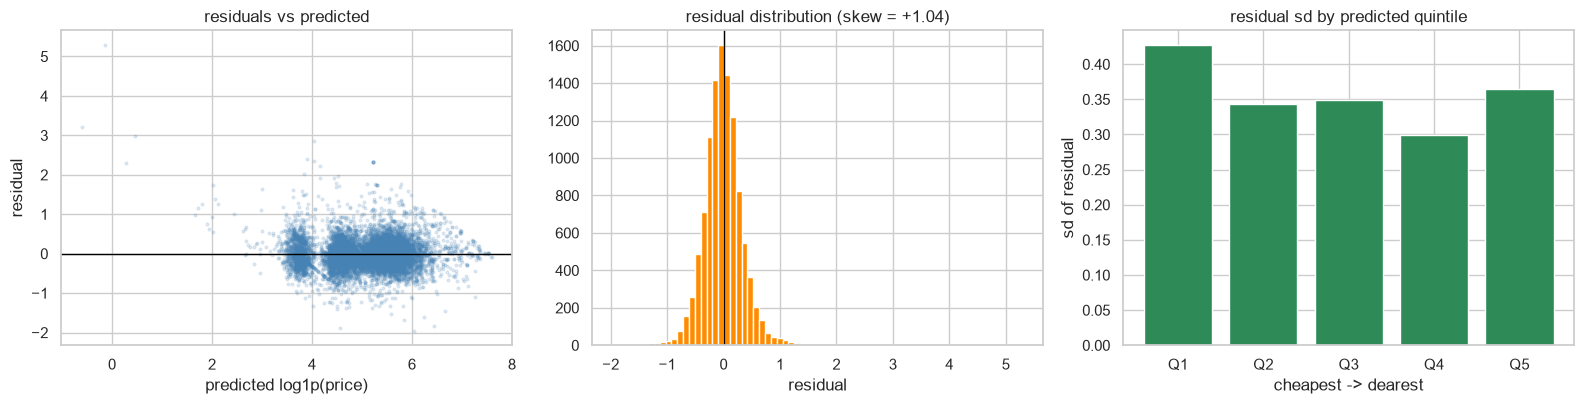

residual mean : -0.0038   (should be ≈ 0)
residual sd   : 0.3593
residual skew : +1.044

sd by predicted quintile:
Q1    0.4267
Q2    0.3436
Q3    0.3485
Q4    0.2986
Q5    0.3641


In [ ]:
# TODO: Produce three residual diagnostics for the Ridge model and interpret each.
#
#   1. residuals vs predicted values  - looking for pattern and for changing spread
#   2. a histogram of residuals        - looking for skew and heavy tails
#   3. residual standard deviation by predicted quintile - quantifying (2)
#
# For each, write what you see AND what it implies about the model.
#
# Use cross_val_predict so that every prediction is out-of-fold.

# cross_val_predict returns one prediction per row, each made by a model that never
# saw that row in training. Residuals from in-sample predictions would look far too
# good and would hide exactly the patterns we are looking for.
pred = cross_val_predict(Pipeline([("prep", preprocessor), ("model", Ridge())]),
                         X, y, cv=gkf, groups=groups)
# residual = truth minus prediction, so a positive residual means we under-predicted.
resid = y.to_numpy() - pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1. The canonical diagnostic. What you want is a shapeless band around zero. Any
# curve means the functional form is wrong; any funnel means the error size depends
# on the prediction. alpha=0.15 so that 10,000 overlapping points stay readable.
axes[0].scatter(pred, resid, s=4, alpha=0.15, color="steelblue")
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="residuals vs predicted", xlabel="predicted log1p(price)",
            ylabel="residual")

# 2. Shape of the errors. Skew near zero and no heavy tail is the good case.
axes[1].hist(resid, bins=70, color="darkorange")
axes[1].axvline(0, color="black", lw=1)
axes[1].set(title=f"residual distribution (skew = {pd.Series(resid).skew():+.2f})",
            xlabel="residual")

# 3. The funnel from panel 1, measured rather than eyeballed. qcut cuts the
# predictions into five equal-sized buckets, cheapest to dearest, and we take the
# standard deviation of the residuals within each.
quintile = pd.qcut(pred, 5, labels=[f"Q{i}" for i in range(1, 6)])
spread = pd.Series(resid).groupby(np.asarray(quintile), observed=True).std()
axes[2].bar(spread.index.astype(str), spread.to_numpy(), color="seagreen")
axes[2].set(title="residual sd by predicted quintile", xlabel="cheapest -> dearest",
            ylabel="sd of residual")
plt.tight_layout()
plt.show()

# A mean residual near zero says the model is unbiased on average. It says nothing
# at all about whether it is unbiased in any particular part of the range, which is
# what the third panel is for.
print(f"residual mean : {resid.mean():+.4f}   (should be ≈ 0)")
print(f"residual sd   : {resid.std():.4f}")
print(f"residual skew : {pd.Series(resid).skew():+.3f}")
# The numbers behind panel 3. If Q1 and Q5 differ noticeably, one prediction
# interval quoted for the whole range would be wrong at both ends.
print("\nsd by predicted quintile:")
print(spread.round(4).to_string())

Three findings, three different implications:

**1. The mean residual is ≈ 0.** Expected - OLS guarantees it on the training data,
and it approximately holds out of fold. If it did not, something would be badly
wrong.

**2. The residuals are right-skewed (+1.04).** This is the interesting one. We took
a log *specifically* to remove skew, and the target's skew did drop from 9.04 to
0.03. But the **residual** skew is still +1.0. Fixing the marginal distribution of
the target did not make the errors symmetric. There remain listings that are far
more expensive than their features can explain - the ones with something we have not
measured. RMSE, which squares, is more affected by these than MAE.

**3. The error spread is largest for the cheapest predictions** (sd 0.43 in the
lowest quintile against 0.30 in Q4). The model is *worse at pricing cheap listings*.
That is a fact about the world you can report: budget rooms are priced less
consistently, presumably because they compete on things this dataset does not
record.

That last one is a genuine finding for Client B, and it came from a residual plot
rather than from a score.

### The OLS assumptions, and which ones we just violated

| Assumption | What it buys | Our status |
|---|---|---|
| Linearity in parameters | the model is identifiable | fine - we chose it |
| Errors have mean zero | coefficients are unbiased | fine (≈ 0.00) |
| **Homoscedasticity** | standard errors are valid | **violated** - see quintile 1 |
| Independent errors | standard errors are valid | **violated** - hosts cluster |
| No perfect collinearity | $\mathbf{X}^\top\mathbf{X}$ is invertible | fine |
| Normal errors | *only* needed for exact small-sample inference | violated (skew +1.04) |

**What the violations cost us.** Not the predictions: OLS remains a perfectly
reasonable predictor with heteroscedastic, non-normal, clustered errors. What they
cost is **inference** - any p-value or confidence interval on a coefficient is
untrustworthy here.

This is worth being precise about, because it is a common muddle. We are doing
prediction. We are allowed to violate the assumptions that only inference needs, so
long as we do not then make inferential claims. The moment you say "bedrooms has a
significant effect", you have crossed a line the data does not support.

## §6 - Bias, variance, and the collapse

Overfitting is usually explained with a picture and a warning. We are going to make
it happen, on purpose, and measure it.

Take four numeric features and expand them into polynomial terms of increasing
degree. Degree 1 is the plain linear model. Degree 5 includes every product of up to
five of those features.

- **High bias / underfitting:** the model is too rigid to capture the pattern. Both
  training and validation scores are poor, and close together.
- **High variance / overfitting:** the model fits the training data's noise.
  Training score keeps rising; validation score falls. The gap opens.

### Underfitting beside overfitting

![bias variance](../assets/diagrams/s04_regression/bias-variance.png)

The same points, fitted twice. On the left a line too rigid to follow the shape of the data. On the right a curve flexible enough to pass through almost every point, including the noise.

Before reading on, decide which of the two you would deploy - and then ask which of the two has the lower error *on the points shown*. The answers are not the same, and the gap between them is what the next experiment measures.

### Predict before you run

Sketch, on paper, the training R² and validation R² as degree goes 1 → 5. Mark where
you think validation performance peaks.

 degree  terms  train_r2   val_r2     gap
      1      4    0.7101   0.6940  0.0161
      2     14    0.7557   0.7298  0.0259
      3     34    0.7698   0.7399  0.0300
      4     69    0.7817   0.1143  0.6673
      5    125    0.7892 -20.4313 21.2205


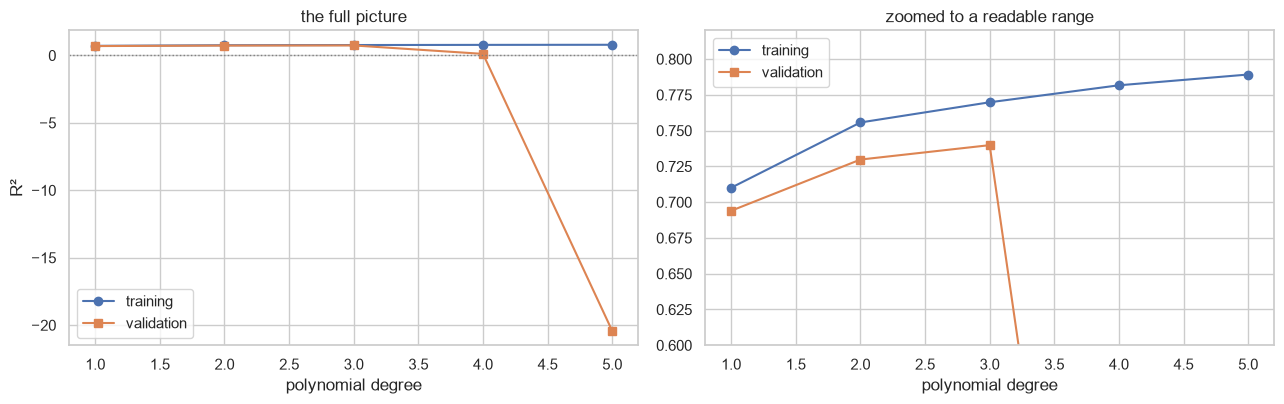

In [11]:
# TODO: Sketch your prediction, then run the sweep.
#
# My prediction: validation R2 peaks at degree ___ and by degree 5 is about ___

# Overfitting, manufactured on purpose. Four features are enough, because the number
# of polynomial terms grows combinatorially with the degree.
POLY_FEATURES = ["accommodates", "bedrooms", "bathrooms", "minimum_nights"]
degrees = [1, 2, 3, 4, 5]
rows = []
for d in degrees:
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        # PolynomialFeatures expands the columns into every product up to degree d,
        # so the model stays linear in its coefficients while the fit becomes
        # curved. include_bias=False because the model has its own intercept.
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        # Scaling matters more here than anywhere else: a fifth power spans an
        # enormous range, and unscaled it would swamp the linear terms.
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1e-6)),   # α ≈ 0: we want the overfitting undamped
    ])
    # return_train_score is the whole point of this cell. Overfitting is not a low
    # validation score, it is a *gap* between training and validation, and you
    # cannot see a gap with one number.
    cv = cross_validate(pipe, work[POLY_FEATURES], y, cv=gkf, groups=groups,
                        scoring="r2", return_train_score=True)
    # How many terms the expansion produced, so the table shows the cost of degree.
    n_terms = PolynomialFeatures(degree=d, include_bias=False).fit(
        work[POLY_FEATURES].fillna(0)).n_output_features_
    rows.append({"degree": d, "terms": n_terms,
                 "train_r2": cv["train_score"].mean(),
                 "val_r2": cv["test_score"].mean()})

sweep = pd.DataFrame(rows)
# The gap column is the definition of overfitting, made into a number you can read.
sweep["gap"] = sweep["train_r2"] - sweep["val_r2"]
print(sweep.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# Left panel: the honest view. Validation R² falls off a cliff at high degree, far
# below zero, which means the model is worse than predicting the mean.
axes[0].plot(sweep["degree"], sweep["train_r2"], "o-", label="training")
axes[0].plot(sweep["degree"], sweep["val_r2"], "s-", label="validation")
# The zero line is the baseline from §2, drawn in so the collapse has a reference.
axes[0].axhline(0, color="grey", lw=1, ls=":")
axes[0].set(title="the full picture", xlabel="polynomial degree", ylabel="R²")
axes[0].legend()

# Right panel: the same curves with the y-axis clipped, because the collapse is so
# large that it flattens everything interesting in the left panel. Two views of one
# result, and it is worth naming that a clipped axis is a choice with consequences.
axes[1].plot(sweep["degree"], sweep["train_r2"], "o-", label="training")
axes[1].plot(sweep["degree"], sweep["val_r2"], "s-", label="validation")
axes[1].set(title="zoomed to a readable range", xlabel="polynomial degree",
            ylim=(0.6, 0.82))
axes[1].legend()
plt.tight_layout()
plt.show()

### What just happened

| degree | terms | train R² | validation R² |
|---:|---:|---:|---:|
| 1 | 4 | 0.710 | 0.694 |
| 2 | 14 | 0.756 | 0.730 |
| 3 | 34 | 0.770 | **0.740** ← best |
| 4 | 69 | 0.782 | **0.114** |
| 5 | 125 | 0.789 | **−20.43** |

Training R² **rises monotonically** from 0.710 to 0.789. If you only looked at
training performance, degree 5 is your best model. It is, in fact, catastrophic.

A validation R² of **−20** means the model's squared error is twenty-one times worse
than simply predicting the mean. It has not merely failed to generalise; it is
actively harmful. Nothing in the training score hints at this.

**Two lessons, both worth more than the plot:**

1. **Training performance is not evidence.** It is the one number that is guaranteed
   to improve as you add capacity, which makes it useless as a guide.
2. **Failure can be sudden.** Degree 3 is fine and degree 4 is ruined. There is no
   gentle warning slope. This is why you check, every time, rather than reasoning
   about whether a model "should" be complex enough to overfit.

Notice also that the second panel needed a different y-axis. Whenever one point
destroys your plot's scale, that point is the finding.

## §7 - Common mistakes

| Mistake | Why it is tempting | What to do instead |
|---|---|---|
| Reporting R² with no baseline | it looks like a percentage | our baseline is −0.011 with RMSE 0.829. Quote both. |
| Reporting log-space RMSE to a client | it is what the code printed | translate: exp(RMSE) is a multiplicative factor |
| Reading a coefficient as an effect | the word "effect" is everywhere | it is an association, confounded and scale-dependent |
| Applying Ridge reflexively | it is good practice | here it changes R² by 0.0002. Diagnose before treating. |
| Judging by training score | it is right there | it rose monotonically to a model with R² = −20 |
| `np.linalg.inv` for least squares | it matches the formula | `solve` is faster and better conditioned |
| Claiming significance from OLS output | the software prints p-values | our errors are heteroscedastic and clustered. Prediction is fine; inference is not. |

## §8 - Reflection

1. Client B asks for "an accuracy figure" for the pricing tool. Write the two
   sentences you would actually send, using the numbers from §4.
2. The model is least reliable on the cheapest listings. Name one thing you could
   add to the dataset that might fix this, and say how you would test whether it did.
3. We violated homoscedasticity and normality and carried on. Under what
   circumstance would that have been unacceptable?

## §9 - Knowledge check

1. Write the normal equation and say why `np.linalg.solve` is preferred to
   inverting.
2. Our baseline scored R² = −0.011. Why is it not exactly zero?
3. RMSE = 0.36 on a `log1p` target. What does that mean for a €200 listing?
4. Training R² rose from 0.710 to 0.789 while validation fell to −20.4. Explain in
   terms of bias and variance.
5. Name one OLS assumption we violated and state precisely what it did and did not
   invalidate.

## Summary

- **Baseline first.** Mean-prediction gives R² ≈ 0 and RMSE 0.829. Every later
  number is meaningful only against those.
- Linear regression has a **closed-form solution**, the normal equation. It is the
  only model in this course that does, and Session 8 will show what iteration costs.
- A coefficient on a log target is a **percentage** effect - and an association, not
  a cause.
- **Translate your metrics.** RMSE 0.36 in log space is roughly +43%/−30%: a €177
  listing predicted between about €137 and €229. That is the sentence the client
  needs.
- **Regularisation changed nothing** (0.8078 → 0.8082) because there was no
  overfitting to treat, and Lasso made things worse. Diagnose before you treat.
- Residuals gave us a finding no score could: the model is **least reliable on the
  cheapest listings**.
- We violated homoscedasticity, normality and independence. That invalidates
  **inference**, not prediction - provided we do not then claim significance.
- The polynomial sweep took validation R² from 0.740 to **−20.43** while training R²
  kept rising. Training performance is not evidence.

## Key takeaways

1. No score means anything without a baseline.
2. Report error in the client's units, not the model's.
3. Every technique treats a specific problem. Check you have the problem.

## Further exploration

**Essential**
- James et al., *An Introduction to Statistical Learning*, ch. 3 (linear regression)
  and §2.2 (bias–variance). https://www.statlearning.com/
- scikit-learn user guide, *Linear Models*:
  https://scikit-learn.org/stable/modules/linear_model.html

**Recommended**
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, §3.2 and
  §3.4 for Ridge/Lasso as constrained optimisation.
  https://hastie.su.domains/ElemStatLearn/
- Shmueli (2010), *To Explain or to Predict?*, Statistical Science 25(3) - the
  prediction-versus-inference distinction from §5, argued properly.

**Advanced**
- Belkin et al. (2019), *Reconciling modern machine-learning practice and the
  classical bias–variance trade-off*, PNAS. https://arxiv.org/abs/1812.11118 -
  the classical U-curve you drew in §6 is not the whole story for very
  over-parameterised models. Read it as an open research thread, not a correction.

---

**Next session:** classification, and the discovery that a model doing nothing at
all can score an F1 of 0.80.